In [1]:
###### Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import networkx as nx  # Import NetworkX for graph operations

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import random
from IPython.display import clear_output
from scipy.special import softmax

from sklearn.utils import shuffle

import pickle

In [2]:
%run ../utils/trials_v04.py 

In [3]:
%run ../utils/encoders.py 

In [4]:
%run ../SE_contrastive_learning/agent_contrastive_rl.py

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device", device)

device cuda


In [6]:
# Set Seeds
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)
rng = np.random.default_rng(random_seed)

In [7]:
##### Create Trials

In [8]:
protocols_dict = {f"{ts}_{relation}_{neg_selection}": {
    'train_structure': ts, 
    'relation_type': relation,
    'selection_neg_comp': neg_selection,
    'same_label_param': neg_selection == "Standard"

    } 
    for ts in [
        "LS", 
        "OTM", 
        "MTO"
        ] for relation in [
            'select_reject', 
            'select_only',
            'reject_only', 
        ] for neg_selection in [
            "Standard", 
            "Biased_neg"
            ]
    }
list(protocols_dict.keys())


['LS_select_reject_Standard',
 'LS_select_reject_Biased_neg',
 'LS_select_only_Standard',
 'LS_select_only_Biased_neg',
 'LS_reject_only_Standard',
 'LS_reject_only_Biased_neg',
 'OTM_select_reject_Standard',
 'OTM_select_reject_Biased_neg',
 'OTM_select_only_Standard',
 'OTM_select_only_Biased_neg',
 'OTM_reject_only_Standard',
 'OTM_reject_only_Biased_neg',
 'MTO_select_reject_Standard',
 'MTO_select_reject_Biased_neg',
 'MTO_select_only_Standard',
 'MTO_select_only_Biased_neg',
 'MTO_reject_only_Standard',
 'MTO_reject_only_Biased_neg']

In [ ]:
############################################
    #    Class and members numbers    #
############################################

#six members, five classes _paper_protocol
# experiment 2c evaluates if reject relations is affected by the number of stimulus 
members_number = 5 #6 
classes_number = 5 #5 

####################
## Agent hyperparameters
#####################
agent_params = {
    "n_epochs" : 1, 
    "learning_rate" : .03, #0.025, #.25 #.03,#
    "temperature" : .25,#.1, #.25
    "epsilon" : .3,
    }

In [10]:
experiment_params = {
    "positive_sensitivity" :            {"exp_1": 1., "exp_2c": 1., "exp_2b": 0., "exp_2a":1.}, #default (1)
    "negative_sensitivity" :            {"exp_1": 1., "exp_2c": 1., "exp_2b": 1., "exp_2a":0.}, #default (1)
    "unknown_positive_gradient_ratio" : {"exp_1": .3, "exp_2c": 0., "exp_2b": 0., "exp_2a":0.}, #default (0.1)
    "known_negative_gradient_ratio" :   {"exp_1": 1., "exp_2c": 0., "exp_2b": 1., "exp_2a":0.} #default (1)
}

In [11]:
############################
selected_experim = "exp_2b"
############################

agent_params["positive_sensitivity"] = experiment_params["positive_sensitivity"][selected_experim]
agent_params["negative_sensitivity"] = experiment_params["negative_sensitivity"][selected_experim]
agent_params["unknown_positive_gradient_ratio"] = experiment_params["unknown_positive_gradient_ratio"][selected_experim]
agent_params["known_negative_gradient_ratio"] = experiment_params["known_negative_gradient_ratio"][selected_experim]

In [12]:
pd.DataFrame({
    "positive_sensitivity" : experiment_params["positive_sensitivity"],
    "negative_sensitivity" : experiment_params["negative_sensitivity"],
    "unknown_positive_gradient_ratio" : experiment_params["unknown_positive_gradient_ratio"],
    "known_negative_gradient_ratio" : experiment_params["known_negative_gradient_ratio"]
    }
    ).T

,exp_1,exp_2c,exp_2b,exp_2a
positive_sensitivity,1.0,1.0,0.0,1.0
negative_sensitivity,1.0,1.0,1.0,0.0
unknown_positive_gradient_ratio,0.3,0.0,0.0,0.0
known_negative_gradient_ratio,1.0,0.0,1.0,0.0


In [13]:
protocol_names=list(protocols_dict.keys())

Epoch 1, Loss: 0.6931


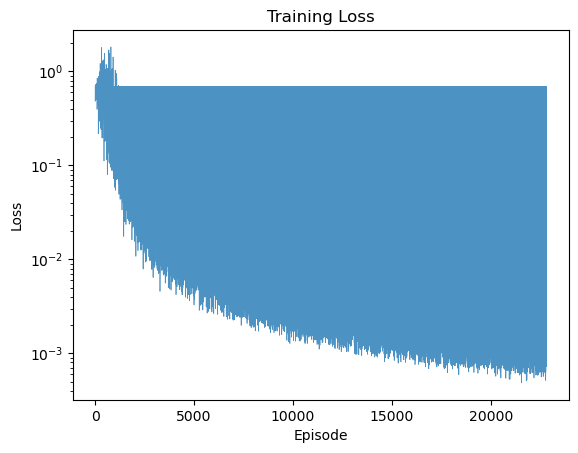

In [14]:
for prt_nm in protocol_names:
    print ("Training ", prt_nm)
    protocol = protocols_dict[prt_nm]

    ## # Instantiate trials creator class
    protocol_trials = TrialsGenerator(
        members_n = members_number, 
        classes_n = classes_number, 
        train_structure = protocol["train_structure"],
        relation_type = protocol["relation_type"],
        same_label_filter = protocol["same_label_param"]
    )

    baseline_train_trials_info = protocol_trials.baseline_trials_info
    reflexivity_trials_info = protocol_trials.reflexivity_trials_info
    symmetry_trials_info = protocol_trials.symmetry_trials_info
    transitivity_trials_info = protocol_trials.transitivity_trials_info

    trials_encoder_onehot = OneHotEncoderTrials(protocol_trials)
    agent_embeddings = dict(
        zip(
            list(
                trials_encoder_onehot.stimuli_dict_encoded.keys()
            ),np.array(list(trials_encoder_onehot.stimuli_dict_encoded.values()
                        )
                    ).astype("float") 
        )
    )
    options_dict = {'O_1':0, 'O_2':1, 'O_3':2} # this is needed deep into the agent train # verify this error    

    ####################################
    #### Train agent
    ####################################
    trained_stimuli_embedd_dict = train_q_network(
        trials_info_df = baseline_train_trials_info, 
        embedded_stimuli_dict = agent_embeddings.copy(),
        **agent_params 
    )

    baseline_train_responses_df = get_evaluation_responses(test_trials_info_df = baseline_train_trials_info, trained_embedding_stimuli_dict = trained_stimuli_embedd_dict)
    reflexivity_responses_df = get_evaluation_responses(test_trials_info_df = reflexivity_trials_info, trained_embedding_stimuli_dict = trained_stimuli_embedd_dict)
    symmetry_responses_df = get_evaluation_responses(test_trials_info_df = symmetry_trials_info, trained_embedding_stimuli_dict = trained_stimuli_embedd_dict)
    transitivity_responses_df = get_evaluation_responses(test_trials_info_df = transitivity_trials_info, trained_embedding_stimuli_dict = trained_stimuli_embedd_dict)

    protocol_output = pd.concat([
        baseline_train_responses_df,
        reflexivity_responses_df,
        symmetry_responses_df,
        transitivity_responses_df],
        axis=0, 
        ignore_index=True)
    
    protocol["trained_stimuli_embedd_dict"] = trained_stimuli_embedd_dict
    protocol["protocol_output"] = protocol_output
    



In [15]:
# save experiment dictionarie pickle

with open('salidas/protocols_dict.pickle', 'wb') as f:
    pickle.dump(protocols_dict, f, pickle.HIGHEST_PROTOCOL)
